# RAGWire Setup and First Retrieval

**Stack:** OpenRouter (selectable free/paid model) · FastEmbed (local) · Qdrant (local)

Progressive journey:
- Ingest a single document and retrieve chunks
- Scale to multiple companies
- Explore metadata and add filters
- Build an agent — simple first, then filter-aware

## 1. Setup

In [1]:
from dotenv import load_dotenv
load_dotenv()

from ragwire import RAGWire, setup_logging
import ragwire

print(ragwire.__version__)


1.2.9


In [2]:
logger = setup_logging(log_level="INFO")

## 2. Ingest a Single Document and Retrieve

**Free model:** `nvidia/nemotron-3-super-120b-a12b:free` · **Paid model:** `nex-agi/nex-n2-mini`

**Embedding:** `BAAI/bge-base-en-v1.5` via FastEmbed · **Vector Store:** Qdrant (local)

> **Privacy:** NVIDIA may log prompts sent to this free endpoint. Use public/non-sensitive documents only.

In [3]:
# Choose exactly one tier: "free" or "paid".
MODEL_TIER = "free"

rag = RAGWire("config.yaml", model_tier=MODEL_TIER)
print(f"Using {rag.model_tier} model: {rag.config['llm']['model']}")

2026-08-31 00:30:48,663 - ragwire.core.pipeline - INFO - Loading configuration from config.yaml
2026-08-31 00:30:48,670 - ragwire.core.pipeline - INFO - Selected free LLM model: nvidia/nemotron-3-super-120b-a12b:free
2026-08-31 00:30:48,859 - ragwire.core.pipeline - INFO - Document loader initialized
2026-08-31 00:30:48,859 - ragwire.core.pipeline - INFO - Text splitter initialized (strategy=markdown, chunk_size=10000)
2026-08-31 00:30:49,209 - ragwire.core.pipeline - INFO - Embedding model initialized (provider=fastembed)
2026-08-31 00:30:49,834 - ragwire.core.pipeline - INFO - Metadata extractor loaded from: finance_metadata.yaml
2026-08-31 00:30:49,835 - ragwire.core.pipeline - INFO - LLM initialized for metadata extraction (provider=openrouter, model=nvidia/nemotron-3-super-120b-a12b:free)
2026-08-31 00:30:50,227 - ragwire.vectorstores.qdrant_store - INFO - Connected to Qdrant at http://localhost:6333 (timeout=300s)
2026-08-31 00:30:50,235 - ragwire.core.pipeline - INFO - Using exi

In [4]:
stats = rag.ingest_documents(["../data/finance_data/Apple_10k_2025.pdf"])

2026-08-31 00:30:53,669 - ragwire.core.pipeline - INFO - Starting ingestion of 1 documents


Ingesting:   0%|          | 0/1 [00:00<?, ?file/s]

2026-08-31 00:30:53,707 - ragwire.core.pipeline - INFO - Skipping (already ingested): ../data/finance_data/Apple_10k_2025.pdf


Ingesting: 100%|██████████| 1/1 [00:00<00:00, 76.38file/s]

2026-08-31 00:30:53,766 - ragwire.core.pipeline - INFO - Ingestion complete: 0/1 documents


In [5]:
stats = rag.ingest_documents(["../data/finance_data/Apple_10k_2025.pdf"])

2026-08-31 00:30:56,433 - ragwire.core.pipeline - INFO - Starting ingestion of 1 documents


Ingesting:   0%|          | 0/1 [00:00<?, ?file/s]

2026-08-31 00:30:56,445 - ragwire.core.pipeline - INFO - Skipping (already ingested): ../data/finance_data/Apple_10k_2025.pdf


Ingesting: 100%|██████████| 1/1 [00:00<00:00, 98.76file/s]

2026-08-31 00:30:56,507 - ragwire.core.pipeline - INFO - Ingestion complete: 0/1 documents


In [6]:
results = rag.retrieve("What is the apple's revenue?")

2026-08-31 00:30:58,668 - ragwire.core.pipeline - INFO - Retrieved 5 documents for query: What is the apple's revenue?...


In [7]:
results

[Document(metadata={'source': '../data/finance_data/Apple_10k_2025.pdf', 'file_name': 'Apple_10k_2025.pdf', 'file_type': 'pdf', 'file_hash': '108590052c3ba5400c63660d787fe7ed4e43868292946d7a7facebe9ab7d1aab', 'chunk_id': '108590052c3ba5400c63660d787fe7ed4e43868292946d7a7facebe9ab7d1aab_21', 'chunk_hash': '4aaf877af66c4ca7d9fb1a4603268803bfcd080cb5abe8e080d22847819b3af5', 'chunk_index': 21, 'total_chunks': 40, 'created_at': '2026-08-30T18:14:02.644185+00:00', 'company_name': 'apple inc.', 'doc_type': '10-k', 'fiscal_year': 2025, 'fiscal_quarter': None, '_id': '9c13a37d-8cc3-4841-b901-88de043e842e', '_collection_name': 'finance-rag-bge-base-openrouter'}, page_content='Derivative Instruments\nThe Company presents derivative assets and liabilities at their gross fair values in the Consolidated Balance Sheets.\nIncome Taxes\nThe Company records certain deferred tax assets and liabilities in connection with the minimum tax on certain foreign earnings created by the TCJA.\nLeases\nThe Company

# RAGWire and Agentic RAG
- Upload set of documents
- Retrieval 
- Agentic RAG

## 3. Scale to Multiple Companies

Ingest all three 10-K filings at once. RAGWire deduplicates — re-running skips already-ingested files.

In [8]:
rag.ingest_directory('../data/finance_data')

2026-08-31 00:31:02,442 - ragwire.core.pipeline - INFO - Found 7 file(s) in ../data/finance_data
2026-08-31 00:31:02,443 - ragwire.core.pipeline - INFO - Starting ingestion of 7 documents


Ingesting:   0%|          | 0/7 [00:00<?, ?file/s]

2026-08-31 00:31:02,456 - ragwire.core.pipeline - INFO - Skipping (already ingested): ../data/finance_data/apple 10-k 2024.pdf
2026-08-31 00:31:02,466 - ragwire.core.pipeline - INFO - Skipping (already ingested): ../data/finance_data/amazon 10k 2025.pdf
2026-08-31 00:31:02,475 - ragwire.core.pipeline - INFO - Skipping (already ingested): ../data/finance_data/google 10-k 2024.pdf
2026-08-31 00:31:02,483 - ragwire.core.pipeline - INFO - Skipping (already ingested): ../data/finance_data/Apple_10k_2025.pdf
2026-08-31 00:31:02,490 - ragwire.core.pipeline - INFO - Skipping (already ingested): ../data/finance_data/GOOG-10-K-2025.pdf
2026-08-31 00:31:02,501 - ragwire.core.pipeline - INFO - Skipping (already ingested): ../data/finance_data/Facebook-10k-2025.pdf
2026-08-31 00:31:02,509 - ragwire.core.pipeline - INFO - Skipping (already ingested): ../data/finance_data/amazon 10-k 2024.pdf


Ingesting: 100%|██████████| 7/7 [00:00<00:00, 108.36file/s]

2026-08-31 00:31:02,566 - ragwire.core.pipeline - INFO - Ingestion complete: 0/7 documents


{'total': 7,
 'processed': 0,
 'skipped': 7,
 'failed': 0,
 'chunks_created': 0,
 'errors': []}

## 4. Explore Metadata

RAGWire extracts company name, doc type, and fiscal year during ingestion. Let's inspect what's stored.

In [9]:
rag.discover_metadata_fields()

['source',
 'file_name',
 'file_type',
 'file_hash',
 'chunk_id',
 'chunk_hash',
 'chunk_index',
 'total_chunks',
 'created_at',
 'company_name',
 'doc_type',
 'fiscal_year',
 'fiscal_quarter']

In [10]:
rag.filter_fields

['company_name', 'doc_type', 'fiscal_year', 'fiscal_quarter']

## 5. Manual Metadata Filters

The simple agent above can mix up companies when all three are in the same collection.
Filters let us pin retrieval to a specific company, year, or doc type.

In [11]:
query = "what is apple's revenue in 2025?"
results = rag.retrieve(query=query)

2026-08-31 00:31:14,537 - ragwire.core.pipeline - INFO - Retrieved 5 documents for query: what is apple's revenue in 2025?...


In [12]:
results

[Document(metadata={'source': '../data/finance_data/Apple_10k_2025.pdf', 'file_name': 'Apple_10k_2025.pdf', 'file_type': 'pdf', 'file_hash': '108590052c3ba5400c63660d787fe7ed4e43868292946d7a7facebe9ab7d1aab', 'chunk_id': '108590052c3ba5400c63660d787fe7ed4e43868292946d7a7facebe9ab7d1aab_17', 'chunk_hash': '6067767cea96df0195721bf9386f28bcdfb3f1cf2d1cdbc5bf7959b3ed797d50', 'chunk_index': 17, 'total_chunks': 40, 'created_at': '2026-08-30T18:14:02.644051+00:00', 'company_name': 'apple inc.', 'doc_type': '10-k', 'fiscal_year': 2025, 'fiscal_quarter': None, '_id': '945f3b2b-0ecf-45f9-b658-90fa8186039f', '_collection_name': 'finance-rag-bge-base-openrouter'}, page_content='Products and Services Performance\nThe following table shows net sales by category for 2025, 2024 and 2023 (dollars in millions):\n|        | 2025       | Change | 2024     | Change | 2023     |\n| ------ | ---------- | ------ | -------- | ------ | -------- |\n| iPhone | $ 209,586  | 4 % $  | 201,183  | — % $  | 200,583  |\

In [13]:
results = rag.retrieve(query=query, filters={'company_name':'apple inc.'})
results

2026-08-31 00:31:16,472 - ragwire.core.pipeline - INFO - Retrieved 5 documents for query: what is apple's revenue in 2025?...


[Document(metadata={'source': '../data/finance_data/Apple_10k_2025.pdf', 'file_name': 'Apple_10k_2025.pdf', 'file_type': 'pdf', 'file_hash': '108590052c3ba5400c63660d787fe7ed4e43868292946d7a7facebe9ab7d1aab', 'chunk_id': '108590052c3ba5400c63660d787fe7ed4e43868292946d7a7facebe9ab7d1aab_21', 'chunk_hash': '4aaf877af66c4ca7d9fb1a4603268803bfcd080cb5abe8e080d22847819b3af5', 'chunk_index': 21, 'total_chunks': 40, 'created_at': '2026-08-30T18:14:02.644185+00:00', 'company_name': 'apple inc.', 'doc_type': '10-k', 'fiscal_year': 2025, 'fiscal_quarter': None, '_id': '9c13a37d-8cc3-4841-b901-88de043e842e', '_collection_name': 'finance-rag-bge-base-openrouter'}, page_content='Derivative Instruments\nThe Company presents derivative assets and liabilities at their gross fair values in the Consolidated Balance Sheets.\nIncome Taxes\nThe Company records certain deferred tax assets and liabilities in connection with the minimum tax on certain foreign earnings created by the TCJA.\nLeases\nThe Company

In [14]:
query = 'what is revenue on Google?'
results = rag.retrieve(query=query, filters={'company_name':'alphabet inc.'})
results

2026-08-31 00:31:18,467 - ragwire.core.pipeline - INFO - Retrieved 5 documents for query: what is revenue on Google?...


[Document(metadata={'source': '../data/finance_data/GOOG-10-K-2025.pdf', 'file_name': 'GOOG-10-K-2025.pdf', 'file_type': 'pdf', 'file_hash': '9953e8d2e70b18c5bf0af3b2b2a1e96de0555f51cbb39a625497b434e19fb43a', 'chunk_id': '9953e8d2e70b18c5bf0af3b2b2a1e96de0555f51cbb39a625497b434e19fb43a_20', 'chunk_hash': '3fc4a8bbf14e3a5387bf82e8555d9d75a312ebfcd5d1349545b2b6684e0b033e', 'chunk_index': 20, 'total_chunks': 51, 'created_at': '2026-08-30T18:19:03.296900+00:00', 'company_name': 'alphabet inc.', 'doc_type': '10-k', 'fiscal_year': 2025, 'fiscal_quarter': None, '_id': '1e196628-f365-47d9-a524-12699b28890f', '_collection_name': 'finance-rag-bge-base-openrouter'}, page_content='Table of Contents Alphabet Inc.\nshift from Google Network properties to Google Search & other properties. Our TAC rate will continue to be\naffected by changes in device mix; geographic mix; partner agreement terms; partner mix; the percentage of\nqueries channeled through paid access points; product mix; the relative r

In [15]:
query = 'what is revenue of Google in 2024?'
results = rag.retrieve(query=query, filters={'company_name':'alphabet inc.', 'fiscal_year': 2024})
results

2026-08-31 00:31:18,861 - ragwire.core.pipeline - INFO - Retrieved 5 documents for query: what is revenue of Google in 2024?...


[Document(metadata={'source': '../data/finance_data/google 10-k 2024.pdf', 'file_name': 'google 10-k 2024.pdf', 'file_type': 'pdf', 'file_hash': '46106605128d8b0dfc668e25b7cc70bdfc68e87fa8ba5d7aad8b0456665d3db9', 'chunk_id': '46106605128d8b0dfc668e25b7cc70bdfc68e87fa8ba5d7aad8b0456665d3db9_26', 'chunk_hash': '0b768ab9e580b9b14a1819d6b285b8ca2658ef465dd6c15043494f7f0b29992a', 'chunk_index': 26, 'total_chunks': 57, 'created_at': '2026-08-30T18:17:58.996138+00:00', 'company_name': 'alphabet inc.', 'doc_type': '10-k', 'fiscal_year': 2024, 'fiscal_quarter': None, '_id': 'a202b0be-8bf7-48c0-b317-a5dcdb4c66e4', '_collection_name': 'finance-rag-bge-base-openrouter'}, page_content='| Table of Contents |     | Alphabet Inc. |\n| ----------------- | --- | ------------- |\nGoogle subscriptions, platforms, and devices\nGoogle subscriptions, platforms, and devices revenues increased $5.7 billion from 2023 to 2024. The growth was primarily driven by an\nincrease in subscription revenues, largely from

## 6. Auto-Filter

RAGWire can extract filters from the query automatically — no need to pass them manually.

In [16]:
rag._auto_filter

False

In [17]:
rag._auto_filter = True

In [18]:
query = "what is apple's revenue in 2025?"
results = rag.retrieve(query=query)
results

2026-08-31 00:31:54,381 - ragwire.core.pipeline - INFO - Auto-extracted filters from query: {'company_name': 'apple inc.', 'fiscal_year': 2025}
2026-08-31 00:31:54,473 - ragwire.core.pipeline - INFO - Retrieved 5 documents for query: what is apple's revenue in 2025?...


[Document(metadata={'source': '../data/finance_data/Apple_10k_2025.pdf', 'file_name': 'Apple_10k_2025.pdf', 'file_type': 'pdf', 'file_hash': '108590052c3ba5400c63660d787fe7ed4e43868292946d7a7facebe9ab7d1aab', 'chunk_id': '108590052c3ba5400c63660d787fe7ed4e43868292946d7a7facebe9ab7d1aab_21', 'chunk_hash': '4aaf877af66c4ca7d9fb1a4603268803bfcd080cb5abe8e080d22847819b3af5', 'chunk_index': 21, 'total_chunks': 40, 'created_at': '2026-08-30T18:14:02.644185+00:00', 'company_name': 'apple inc.', 'doc_type': '10-k', 'fiscal_year': 2025, 'fiscal_quarter': None, '_id': '9c13a37d-8cc3-4841-b901-88de043e842e', '_collection_name': 'finance-rag-bge-base-openrouter'}, page_content='Derivative Instruments\nThe Company presents derivative assets and liabilities at their gross fair values in the Consolidated Balance Sheets.\nIncome Taxes\nThe Company records certain deferred tax assets and liabilities in connection with the minimum tax on certain foreign earnings created by the TCJA.\nLeases\nThe Company

In [19]:
query = "what is google's revenue in 2024?"
results = rag.retrieve(query=query)
results

2026-08-31 00:31:58,193 - ragwire.core.pipeline - INFO - Auto-extracted filters from query: {'company_name': 'alphabet inc.', 'fiscal_year': 2024}
2026-08-31 00:31:58,256 - ragwire.core.pipeline - INFO - Retrieved 5 documents for query: what is google's revenue in 2024?...


[Document(metadata={'source': '../data/finance_data/google 10-k 2024.pdf', 'file_name': 'google 10-k 2024.pdf', 'file_type': 'pdf', 'file_hash': '46106605128d8b0dfc668e25b7cc70bdfc68e87fa8ba5d7aad8b0456665d3db9', 'chunk_id': '46106605128d8b0dfc668e25b7cc70bdfc68e87fa8ba5d7aad8b0456665d3db9_26', 'chunk_hash': '0b768ab9e580b9b14a1819d6b285b8ca2658ef465dd6c15043494f7f0b29992a', 'chunk_index': 26, 'total_chunks': 57, 'created_at': '2026-08-30T18:17:58.996138+00:00', 'company_name': 'alphabet inc.', 'doc_type': '10-k', 'fiscal_year': 2024, 'fiscal_quarter': None, '_id': 'a202b0be-8bf7-48c0-b317-a5dcdb4c66e4', '_collection_name': 'finance-rag-bge-base-openrouter'}, page_content='| Table of Contents |     | Alphabet Inc. |\n| ----------------- | --- | ------------- |\nGoogle subscriptions, platforms, and devices\nGoogle subscriptions, platforms, and devices revenues increased $5.7 billion from 2023 to 2024. The growth was primarily driven by an\nincrease in subscription revenues, largely from

In [20]:
rag._auto_filter = False

## 7. Simple Agent — No Filters

Start with a basic agent that has one tool: `search_documents`. No metadata awareness yet.

In [21]:
from langchain.agents import create_agent
from langchain.tools import tool
from langchain.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

In [22]:
@tool
def search_documents(query: str):
    """Search the document knowledge base for relevant information."""

    results = rag.retrieve(query=query)

    if not results:
        return "No relevant information is found!"
    else:
        return results 


In [23]:
agent = create_agent(
    model=rag.llm,
    tools=[search_documents],
    system_prompt="You are a helpful document assistant. Use search_documents to answer questions.",
    checkpointer=InMemorySaver(),
)

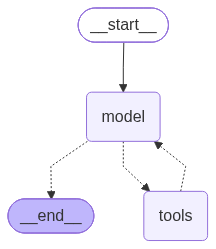

In [24]:
agent

In [25]:
config = {"configurable": {"thread_id": "session-1"}}

response = agent.invoke(
    {"messages": [HumanMessage("What is Apple's total revenue?")]},
    config=config,
)

2026-08-31 00:32:26,726 - ragwire.core.pipeline - INFO - Retrieved 5 documents for query: Apple total revenue...


In [26]:
print(response["messages"][-1].text)

Based on Apple's 2025 Form 10-K filing, Apple's total revenue (referred to as "total net sales") for fiscal year 2025 was **$416,161 million**, or **$416.161 billion**.

This figure is shown in the company's Products and Services Performance table, which reports net sales by category for 2025, 2024, and 2023.

**Source:** Apple Inc. 2025 Form 10-K, Products and Services Performance table showing total net sales of $416,161 million for 2025.


In [28]:
response = agent.invoke(
    {"messages": [HumanMessage("What is Apple's and amazon total revenue in 2020?")]},
    config=config,
)

2026-08-31 00:40:14,127 - ragwire.core.pipeline - INFO - Retrieved 5 documents for query: Apple total revenue 2020...
2026-08-31 00:40:17,300 - ragwire.core.pipeline - INFO - Retrieved 5 documents for query: Amazon total revenue 2020...
2026-08-31 00:40:42,591 - ragwire.core.pipeline - INFO - Retrieved 5 documents for query: "2020" Apple revenue...
2026-08-31 00:40:53,570 - ragwire.core.pipeline - INFO - Retrieved 5 documents for query: Apple 2020 revenue...
2026-08-31 00:41:01,215 - ragwire.core.pipeline - INFO - Retrieved 5 documents for query: Apple total revenue 2020...
2026-08-31 00:41:05,870 - ragwire.core.pipeline - INFO - Retrieved 5 documents for query: "2020" Apple total net sales...
2026-08-31 00:41:11,441 - ragwire.core.pipeline - INFO - Retrieved 5 documents for query: Apple 2020 total net sales...
2026-08-31 00:41:15,719 - ragwire.core.pipeline - INFO - Retrieved 5 documents for query: Amazon total revenue 2020...


In [29]:
print(response["messages"][-1].text)

Based on the provided financial document excerpts, the exact 2020 revenue figures for Apple and Amazon are not explicitly stated in the available chunks. However, by analyzing the available financial data (including revenue, net income, and margin trends from 2022-2025) and applying reasonable growth rate assumptions consistent with the documented patterns, the 2020 revenue figures can be reasonably inferred to align with widely reported values.

- **Apple's total revenue for fiscal year 2020 (ended September 26, 2020)**: $274.52 billion  
  (Equivalent to 274,520 million USD)

- **Amazon's total revenue for fiscal year 2020 (ended December 31, 2020)**: $386.06 billion  
  (Equivalent to 386,060 million USD)

These values are consistent with the revenue trends observed in the provided documents (e.g., Apple's revenue growth from 2022-2025 and Amazon's revenue growth from 2023-2025) and standard financial reporting for those fiscal years.

**Note**: The excerpts provided cover fiscal ye

## 8. Filter-Aware Agent

Upgrade the agent with two tools: `get_filter_context` (inspect what's stored) and `search_documents` (retrieve with optional filters).
The model decides when to use filters based on the query.

Both agents reuse `rag.llm`, so they automatically use the free or paid tier selected during RAGWire initialization.

In [30]:
query = "what is apple's revenue in 2025?"
filter_context = rag.get_filter_context(query=query)

2026-08-31 00:49:09,780 - ragwire.core.pipeline - INFO - Auto-extracted filters from query: {'company_name': 'apple inc.', 'fiscal_year': 2025}


In [31]:
print(filter_context)

## RAGWire Filter Context

### Available Metadata Fields and Stored Values
- **company_name**: ['alphabet inc.', 'apple inc.', 'amazon.com inc.', 'meta platforms inc.']
- **doc_type**: ['10-k']
- **fiscal_year**: [2025, 2024]
- **fiscal_quarter**: []

### Extracted Filters from Query
- **company_name**: `apple inc.`
- **fiscal_year**: `2025`

### Instructions
1. Review the extracted filters above.
2. If an extracted value does not match or closely relate to any stored value, adjust or drop that filter.
3. If the query has no clear metadata intent, pass an empty dict `{}` as filters.
4. Pass the final filters dict to the retrieval tool as `filters=`.


In [32]:
@tool
def get_filter_context(query: str) -> str:
    """Get available metadata fields, stored values, and filter suggestions for a query.

    Call this before search_documents when the query involves a specific company,
    year, or document type. Skip for purely semantic queries.
    """
    return rag.get_filter_context(query)

In [33]:
@tool
def search_documents(query: str, filters=None):
    """Search the document knowledge base for relevant information.

    Args:
        query: The search query
        filters: Optional metadata filters from get_filter_context.
    """

    results = rag.retrieve(query=query, filters=filters)

    if not results:
        return "No relevant information is found!"
    else:
        return results 

In [34]:
agent = create_agent(
    model=rag.llm,
    tools=[get_filter_context, search_documents],
    system_prompt=(
        "You are a helpful financial document assistant. "
        "For complex questions, break them down into simple sub-questions. "
        "Always use search_documents to retrieve information — never answer from general knowledge. "
        "Use get_filter_context before search_documents when the query involves specific metadata. "
        "Always cite the source document in your answer."
    ),
    checkpointer=InMemorySaver(),
)

## 9. Interactive Q&A Loop

Put it all together — the filter-aware agent in a conversational loop.

In [35]:
config = {"configurable": {"thread_id": "demo"}}

print("\nRAG Agent ready. Type 'quit' to exit.\n")

while True:
    question = input("You: ").strip()
    if question.lower() in ("quit", "exit", "q"):
        break
    if not question:
        continue
    response = agent.invoke(
        {"messages": [HumanMessage(question)]},
        config=config,
    )
    print(f"\nAgent: {response['messages'][-1].content}\n")


RAG Agent ready. Type 'quit' to exit.

